# Vorrechenübung 2: Finite-Differenzen-Methode
Themen dieser Vorrechenübung sind:
* 1D-FDM
    * Vorwärtsdifferenzen
    * Zentraldifferenzen
    * 3-Punkt-Zentraldifferenzen
    * Konvergenzanalyse
* 2D-FDM

In [1]:
import numpy as np
from scipy.linalg import solve
from helper_functions import plot_force
from helper_functions import plot_deflection
from helper_functions import plot_convergence
from helper_functions import plot_heat

## 1D-Finite-Differenzen: Der Kragarm 
Gegeben sein ein Kragarm mit einer allgemeinen Linienlast $q(x)$ und der eingeprägten Kraft $F$ am freien Ende. Der Balken habe einen kreisförmigen Querschnitt mit dem Durchmesser $d(x)$. Außerdem sei der E-Modul $E = 1 \cdot 10^5 \frac{N}{m^2}$ gegeben. Gesucht sind der Querkraftverlauf $Q(x)$, der Biegemomentenverlauf $M(x)$ und die Durchbiegung $w(x)$.

<img src="Kragarm.png" style="width: 50%;">

Um das Problem mit der FDM lösen zu können, muss der betrachtete Balken zunächst diskretisiert und freigeschnitten werden.

<img src="Diskretisierung.png" style="width: 50%;">

### Modellparameter

In [2]:
N = 11                                          # number of points
L = 1                                           # length of the cantilever in m
q = 0                                           # line load in N/m
F = 1                                           # load at the tip of the cantilever in N
E = 1e5                                         # Youngs modulus in N/m^2

delta_x = L/(N-1)                               # Step size in m
x_axis = np.linspace(0, L, N)                   # x-positions to be evaluated in m
d = 0.1*np.ones((1,N))                          # Beam diameter at every x-position to be evaluated in m    
# d(7) = 0.05;
# d = 0.15-x_axis*0.1;                          # Variable diameter of the beam in m

I = np.array([np.pi/64*d_val**4 for d_val in d])    # Moment of inertia at every x-position to be evaluated in m^4

### Querkraft (Vorwärtsdifferenzen)
Für den Zusammenhang zwischen der Linienlast $q(x)$ und der Querkraft $Q(x)$ gilt folgender Ausdruck
$$
\frac{dQ(x)}{dx} = - q(x)
$$
Dieser wird mittels Vorwärtsdifferenzen diskretisiert:
$$
\frac{Q_{i+1} + Q_i}{\Delta x} = - q_i
$$
Umstellen und Überführen in die kompakte Koeffizientenschreibweise ergibt:
$$
Q_i =  Q_{i+1} - q_i \cdot \Delta x \\
\alpha ^i _P \cdot Q_i = \alpha ^i _E \cdot Q_{i+1} + f_i
$$
Im Allgemeinen müsssen die Koeffizienzen $\alpha ^i _P, \alpha ^i _E, f_i$ für jeden Punkt $i$ neu berechnet und in den gezeigten Ausdruck eingesetzt werden. Im gezeigten Beispiel gilt jedoch $\alpha ^i _P = \alpha ^i _E = 1$. Der letzte betrachtete Punkt ist als Sonderfall zu betrachten, da der "darauffolgende" Punkt $Q_{i+1}$ außerhalb des Gitters liegt. Dadurch fällt eine Gleichung weg, die jedoch durch die Randbedingung ausgeglichen wird. Diese ist gegeben als die eingeprägte Kraft $F$. Es gilt:
$$
Q(x=L) = F
$$
In der diskretisierten Schreibweise gilt an der Stelle $x=L$:
$$
\alpha ^{N} _P \cdot Q_{N} = F
$$
Iterieren über alle Punkte $i$ führt auf das LGS $\boldsymbol{K \cdot Q} = \boldsymbol{f}$, wobei jede Zeile die Berechnung an einem Punkt repräsentiert und die Randbedingung in der letzten Zeile integriert ist:
$$
\begin{bmatrix}
    \alpha ^1 _P & -\alpha ^1 _E & 0 & 0 & ... & 0\\
    0 & \alpha ^2 _P & -\alpha ^2 _E &  0 & ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    0 & ...  & ... & 0 & 0 & \alpha ^N _P\\
\end{bmatrix}
\cdot
\begin{bmatrix}
Q_1 \\
Q_2 \\
\vdots \\
Q_N
\end{bmatrix}
=
\begin{bmatrix}
f_1\\
f_2\\
\vdots\\
F
\end{bmatrix}
$$

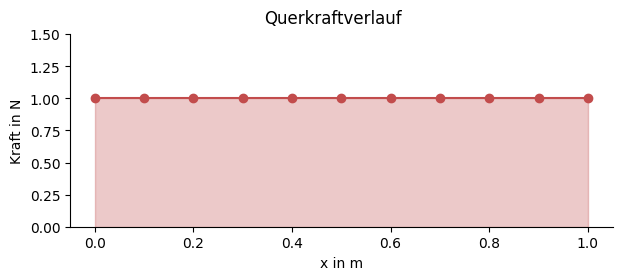

In [3]:
a_P = lambda idx: 1
a_E = lambda idx: 1
f_i = lambda idx: -q * delta_x

# Assembling the stiffness matrix
K = np.zeros((N, N))
for idx in range(N):
    K[idx][idx] = a_P(idx)          # Major diagonal
    
    if idx+1 < N:
        K[idx][idx+1] = - a_E(idx)  # Minor diagonal

# Calculating the load vector
f = np.array([f_i(idx) for idx in range(N)])

# Adding the boundary condition
f[-1] = F

# Solving the system of equations
Q = solve(K, f)

plot_force(x_axis, Q, "Querkraftverlauf", "Kraft in N")

### Biegemoment (Zentraldifferenzen)
Für den Zusammenhang zwischen der Querkraft $Q(x)$ und dem Biegemoment $M(x)$ gilt folgender Ausdruck
$$
\frac{dM(x)}{dx} = Q(x)
$$
Dieser wird mittels Zentraldifferenzen diskretisiert:
$$
\frac{M_{i+1} - M_{i-1}}{2 \Delta x} = Q_i
$$
Umstellen und Überführen in die kompakte Koeffizientenschreibweise ergibt:
$$
0 =  M_{i-1} - M_{i+1} + 2 \Delta x \cdot Q_i\\
0 =  \alpha ^i _W \cdot M_{i-1} + \alpha ^i _E \cdot M_{i+1} + f_i
$$
Die Punkte $i = 1$ und $i = N$ müssen gesondert betrachtet werden, da hier jeweils der Wert $M_{i-1}$ bzw. $M_{i+1}$ außerhalb des Gitters liegt. Hierdurch fallen zwei Gleichungen (Zeilen in der Matrix) weg, sodass das LGS zunächst unterbestimmt ist. Die erste Bedinung kann jedoch wie zuvor wieder mittels einer Randbedingung hinzugefügt werden.
$$
M(x=L) = 0\\
\alpha ^{N} _P \cdot M_{N} = 0
$$
Die zweite Gleichung kann "aufgefüllt" werden, indem der letzte Punkt mittels Rückwärtsdifferenzen betrachtet wird.
$$
\frac{M_N-M_{N-1}}{\Delta x} = Q_N\\
M_N = M_{N-1} + \Delta x \cdot Q_N
$$
Unter Einbezug der Randbedingung und der Rückwärtsdifferenzen als zusätzliche Gleichungen, entsteht folgendes Gleichungssystem:
$$
\begin{bmatrix}
    0 & 0 & 0 & 0 & ... & \alpha ^N _P\\
    \alpha ^2 _W & 0 & -\alpha ^2 _E & 0 & ... & 0\\
    0 & \alpha ^3 _W &0 & -\alpha ^3 _E &  ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    0 & ...  & ... & 0 & \alpha ^N _W & \alpha ^N _P\\
\end{bmatrix}
\cdot
\begin{bmatrix}
M_1 \\
M_2 \\
M_3\\
\vdots \\
M_N
\end{bmatrix}
=
\begin{bmatrix}
0\\
f_2\\
f_3\\
\vdots\\
\Delta x \cdot Q_N
\end{bmatrix}
$$

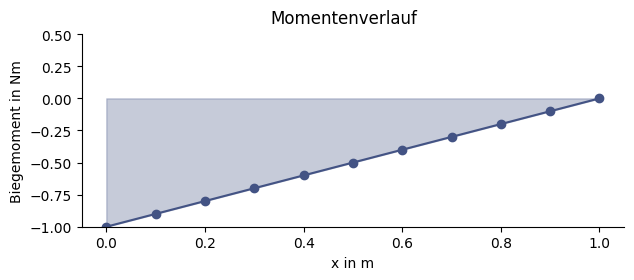

In [4]:
a_W = lambda idx: 1
a_E = lambda idx: - 1
f_i = lambda idx: 2 * delta_x * Q[idx]

# Assembling the stiffness matrix
K = np.zeros((N, N))
for idx in range(1, N-1):           # Note: First and last rows are omitted
    K[idx][idx+1] = - a_E(idx)      # First minor diagonal
    
    if idx > 0:
        K[idx][idx-1] = - a_W(idx)  # Second minor diagonal

# Calculating the load vector
f = np.array([f_i(idx) for idx in range(N)])

# Boundary condition at the right end
K[0, -1] = 1
f[0] = 0

# Backward difference at the right end
K[-1][-1] = 1
K[-1][-2] = -1
f[-1] = delta_x * Q[N-1]

# Solving the system of equations
M = solve(K, f)

plot_force(x_axis, M, "Momentenverlauf", "Biegemoment in Nm")

### Biegelinie (3-Punkt-Zentraldifferenz)
In dieser Aufgabe wird direkt die zweite Ableitungs diskretisiert. Für den Zusammenhang zwischen der Durchbiegung $w(x)$ und dem Biegemoment $M(x)$ gilt folgender Ausdruck
$$
\frac{d^2 w(x)}{dx^2} \cdot EI(x) = -M(x)
$$
Die Verschiebung $w(x)$ wird mittels der 3-Punkt-Zentraldifferenz diskretisiert:
$$
\frac{w_{i-1} - 2 w_i + w_{i+1}}{\Delta x^2} \cdot EI(x) = -M(x)
$$
Umstellen und Überführen in die kompakte Koeffizientenschreibweise ergibt:
$$
-2 w_i =  - w _{i-1}-w_{i+1} + \frac{-M(x) \cdot \Delta x^2}{E I(x)}\\
\alpha ^i _P \cdot w_i=  \alpha ^i _E \cdot w_{i+1} + \alpha ^i _W \cdot w_{i-1} + f_i
$$
Die Punkte $i = 1$ und $i = N$ müssen gesondert betrachtet werden, da hier jeweils der Wert $w_{i-1}$ bzw. $w_{i+1}$ außerhalb des Gitters liegt. Hierdurch fallen zwei Gleichungen weg, sodass das LGS zunächst unterbestimmt ist. Im hier betrachteten Fall können jedoch beide Gleichungen mit Randbedingungen "aufgefüllt" werden. Zunächst die Dirichlet-Randbedingung:
$$
w(x=0) = 0\\
\alpha ^{1} _P \cdot w_{1} = 0 \\
$$
Die Neumann-Randbedingung kann durch Approximieren der Ableitung am Rand durch die 3-Punkt-Vorwärtsdifferenz berücksichtigt werden:
$$
\frac{dw(x=0)}{dx} = 0\\
\frac{-3 w_1 + 4w_2 -w_3}{2 \Delta x} = 0\\
-3 w_1 = -4 w_2 + w_3\\
a_P^1 \cdot w_1 = a_E^1 \cdot w_2 + a_{EE}^1 \cdot w_3 
$$
Unter Einbezug der Randbedingung entsteht folgendes Gleichungssystem:
$$
\begin{bmatrix}
    \alpha ^1 _P & -\alpha ^1 _E & -\alpha ^1 _{EE} & 0 & ... & 0\\
    \alpha ^2 _W & 0 & -\alpha ^2 _E & 0 & ... & 0\\
    0 & \alpha ^3 _W &0 & -\alpha ^3 _E &  ... & 0\\
    \vdots &  &  &  \ddots & & \vdots\\
    \alpha ^1 _P & ...  & ... & 0 & 0 & 0\\
\end{bmatrix}
\cdot
\begin{bmatrix}
w_1 \\
w_2 \\
w_3\\
\vdots \\
w_N
\end{bmatrix}
=
\begin{bmatrix}
0\\
f_2\\
f_3\\
\vdots\\
0
\end{bmatrix}
$$

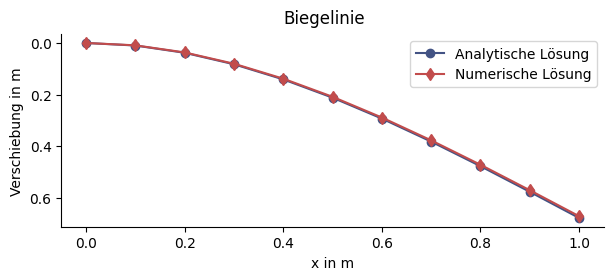

In [5]:
a_W = lambda idx: -1
a_E = lambda idx: - 1
a_P = lambda idx: -2
f_i = lambda idx: -M[idx]*delta_x**2/(E*I[0, idx])

# Assembling the stiffness matrix
K = np.zeros((N, N))
for idx in range(1, N-1):           # Note: First and last rows are omitted
    K[idx][idx] = a_P(idx)          # Major diagonal
    K[idx][idx+1] = - a_E(idx)      # First minor diagonal
    
    if idx > 0:
        K[idx][idx-1] = - a_W(idx)  # Second minor diagonal

# Calculating the load vector
f = np.array([f_i(idx) for idx in range(N)])

# Boundary condition w=0 at the left end
K[0, 0] = 1
f[0] = 0

# Boundary condition dw/dx=0 at the left end
K[-1][0] = -3
K[-1][1] = 4
K[-1][2] = -1
f[-1] = 0

# Solving the system of equations
w = solve(K, f)

# Analytical solution
w_analytical = np.array([F*x**2/(6*E*I[0, idx])*(3*L-x) for idx, x in enumerate(x_axis)])

plot_deflection(x_axis, w, w_analytical, "Biegelinie", "Verschiebung in m")

## Konvergenzanalyse
Nun soll die Konvergenzordnung der gezeigten Verfahren betrachtet werden. Hierzu wird die Differentialgleichung 
$$
u(x) = \frac{df(x)}{dx}
$$
mit
$$
f(x) = sin(x)
$$
gewählt. Die exakte Lösung ist als
$$
u_{exakt}(x) = cos(x)
$$
bekannt. Die Konvergenzordnung kann basierend auf drei numerischen Lösungen $\Phi$ mit unterschiedlicher Schrittweite $h$ geschätzt werden:
$$
p = log_2 \frac{\Phi _ {2h} - \Phi _{4h}}{\Phi _{h} - \Phi _{2h}}
$$


Die Vorwärtsdifferenz hat die geschätzte Konvergenzordnung p = [1.00007223].
Die Zentraldifferenz hat die geschätzte Konvergenzordnung p = [2.00022654].


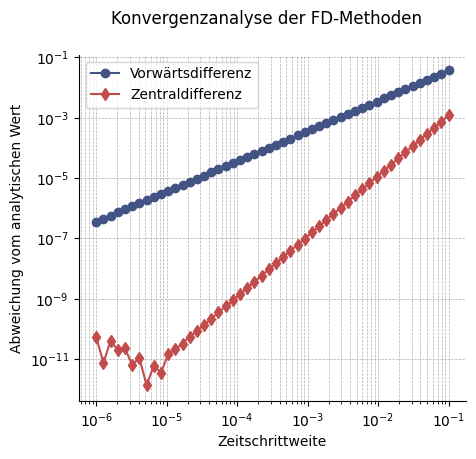

In [6]:
# For the actual calculation
step_sizes = [5e-5, 1e-4, 2e-4]
phi_fds = np.zeros((3, 1))
phi_cds = np.zeros((3, 1))

f = lambda x: np.sin(x)
x0 = np.pi / 4

for idx, h in enumerate(step_sizes):
    phi_fds[idx] = (f(x0 + h) - f(x0)) / h
    phi_cds[idx] = (f(x0 + h) - f(x0 - h)) / (2 * h)

p = lambda phi_h, phi_2h, phi_4h: np.log2((phi_2h-phi_4h)/(phi_h-phi_2h))
p_fds = p(phi_fds[0], phi_fds[1], phi_fds[2])
p_cds = p(phi_cds[0], phi_cds[1], phi_cds[2])

print(f"Die Vorwärtsdifferenz hat die geschätzte Konvergenzordnung p = {p_fds}.")
print(f"Die Zentraldifferenz hat die geschätzte Konvergenzordnung p = {p_cds}.")

# Error as function of step size
step_sizes = np.logspace(-6, -1, 50)
err_fds = np.zeros((50, 1))
err_cds = np.zeros((50, 1))

u_exact = lambda x: np.cos(x)

for idx, h in enumerate(step_sizes):
    err_fds[idx] = abs(u_exact(x0) - (f(x0 + h) - f(x0)) / h)
    err_cds[idx] = abs(u_exact(x0) - (f(x0 + h) - f(x0 - h)) / (2 * h))

plot_convergence(step_sizes, err_fds, err_cds, "Vorwärtsdifferenz", "Zentraldifferenz")


## 2D-Finite-Differenzen: Stationäre Konvektions-Diffusions-Gleichung
<img src="wärmeleitung.png" style="width: 50%;">\
Abschließend wird ein zweidimensionales Wärmeleitungsproblem vorgestellt. Gezeigt ist ein von Wasser umströmter Festkörper. Es wird angenommen, dass das Wasser am Rand des Gebiets die Konstante Temperatur $T = 300 K$ aufweist. Für die Berechnung wird die koaxiale Ansicht genutzt.
Das Gebiet wird mittels eines Gitters mit äquidistanten Schrittweiten diskretisiert. Die Ableitungen werden mit Zentraldifferenzen approximiert. Es entsteht eine Gleichung, die denen der vorherigen Aufgaben sehr ähnelt.
$$
K_E \Phi _{i-1, j} + K_S \Phi _{i, j-1} + K_P \Phi _ {i,j} + K_W \Phi _{i+1, j} + K_N \Phi _ {i, j+1} = f_{i,j}\\
K_{I,I-1} \Phi _{I-1} + K_{I,I-\bar{n}} \Phi _{I-\bar{n}} + K_{I, I} \Phi _ I + K _{I, I+1} \Phi _ {I+1} + K _ {I, I+\bar{n}} \Phi _{I+\bar{n}} = f _I\\
\textrm{wobei } \bar{n} = N_x + 2
$$
Die Koeffizienten $K$ bestehen dabei aus einem konvektiven und einem diffusiven Term.
$$
\textrm{Bsp.: } K_E = - \underbrace{\frac{\rho c_p v_1}{2 \Delta x}}_\text{konv.}  - \underbrace{\frac{\lambda}{\Delta x ^2}}_\text{diff.}
$$
Die geänderte Indexkonvention von $i, j$ zu $I$ kommt daher, dass für die korrekte Implementierung der Matrix die Umrechnung von den Gitterindizes $i, j$ zu den Indizes $I$ der Elemente vorgenommen wird (Bsp.: $(2, 3) \rightarrow 8$ für ein 5x5 Gitter). Die Nummerierung der Elemente startet dabei in der unteren linken Ecke der Platte. Die Umrechnung in Python lautet
$$
I = j \cdot N_x + i
$$
wobei zu beachten ist, dass in Python Indizes ab $0$ gezählt werden (Das Bsp. von oben lautet dann $(2, 3) \rightarrow 13$, da $i_{Py}=0$, $j_{Py}=0$ und $I_{Py}=0$ ebenfalls dazugezählt werden).\
Wie bereits bei den vorherigen 1D-Beispielen, liegen beim Anwenden der Zentraldifferenz einige Punkte außerhalb des Gitters. Hierfür werden wieder Dirichlet-Randbedingungen genutzt, die analog zu den anderen Beipsielen implementiert sind. Der Wärmestrom in der Mitte der Platte wird über Neumann-Randbedingungen in die Rechnung integriert. Dabei wird die Rückwärtsdifferenz genutzt.

c:\Users\phili\Documents\CPS HiWi\LectureNSM\02_finite_differences\python\helper_functions.py:55: UserWarning: Adding colorbar to a different Figure <Figure size 1100x400 with 3 Axes> than <Figure size 450x450 with 0 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(heat, ax=ax1)
c:\Users\phili\Documents\CPS HiWi\LectureNSM\02_finite_differences\python\helper_functions.py:60: UserWarning: Adding colorbar to a different Figure <Figure size 1100x400 with 4 Axes> than <Figure size 450x450 with 0 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(temp, ax=ax2)


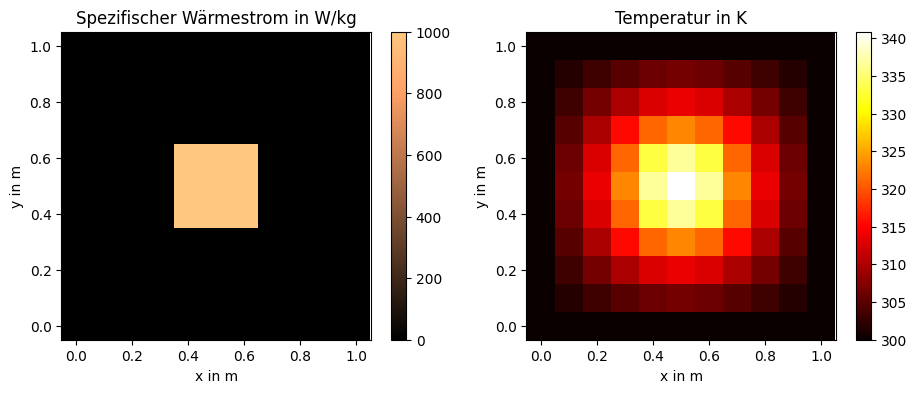

<Figure size 450x450 with 0 Axes>

In [ ]:
# Model parameters
L_x = 1.0                   # x dimension of the plate in m
L_y = 1.0                   # y dimension of the plate in m
rho = 1.0e3                 # Density of the medium (here: water) in kg/m^3
c_p  = 4.18e3               # heat capacity in J/(kg K)
lambd   = 0.6               # thermal conductivity in W/(m K)
alpha = lambd/(rho*c_p)     # thermal diffusivity in m^2/s
v_1 = 0                     # x speed in m/s
v_2 = 0                     # y speed in m/s

# Grid parameters
N_x = 11                    # Discrete points in x direction
N_y = 11                    # Discrete points in y direction
delta_x = L_x/(N_x-1)       # Step size in x direction in m
delta_y = L_y/(N_y-1)       # Step size in y direction in m
N = N_x * N_y               # Total degrees of freedom
K = np.zeros((N, N))        # Stiffness matrix
f = np.zeros((N+2, 1))      # Load vector
node_transform = lambda i, j: j*N_x + i  # Conversion from grid index (i, j) to degree of freedom index (I) ( = row in load vector)

# Inner nodes
a_W = lambda idx: -(rho*c_p*v_1)/(2*delta_x) - lambd/(delta_x**2)
a_E = lambda idx: (rho*c_p*v_1)/(2*delta_x) - lambd/(delta_x**2)
a_P = lambda idx: (2*lambd)/(delta_x**2)+(2*lambd)/(delta_y**2)
a_N = lambda idx: (rho*c_p*v_2)/(2*delta_y) - lambd/(delta_y**2)
a_S = lambda idx: -(rho*c_p*v_2)/(2*delta_y) - lambd/(delta_y**2)

# Assembling the stiffness matrix for all the inner nodes
for i in range(1, N_x-1):
    for j in range(1, N_y-1):            # Note: Border elements are ommited for now
        I = node_transform(i, j)                

        K[I][I-1] = a_W(I)               # Note: Different sign as previously examples due to new definition
        K[I][I-N_x] = a_S(I)
        K[I][I] = a_P(I)
        K[I][I+1] = a_E(I)
        K[I][I+N_x] = a_N(I)

# Add Neumann boundary conditions at location of the heat source
# Define heat source in spatial coordinates first (dimension N_x x N_y)
source_size = 3                        # dimension of source in number of points per side
Q_0 = 1000                             # heat flux in W
heat_source = np.zeros((N_x, N_y))
heat_source[round(N_x/2-source_size/2):round(N_x/2+source_size/2), round(N_y/2-source_size/2):round(N_y/2+source_size/2)] = Q_0

# Flattening the heat source to be a vector (each row now corresponds to one element)
f = heat_source.flatten()

# Add Dirichlet boundary conditions at the edge of the plate. This adds info to rows that were previously skipped when only
# lookning at inner nodes
T_0 = 300                               # Temperature at the edge in K

for i in range(N_x):                    # Top and bottom edge
  for j in [0, N_y-1]:
    I = node_transform(i, j) 
    K[I,I] = 1
    f[I] = T_0

for j in range(1, N_y-1):               # Left and right edge                          
  for i in [0, N_x-1]:
    I = node_transform(i, j) 
    K[I,I] = 1
    f[I] = T_0

phi = solve(K, f)

# Plotting the results
x = np.linspace(0, L_x, N_x)
y = np.linspace(0, L_y, N_y)
X, Y = np.meshgrid(x, y)
Phi = phi.reshape(N_y, N_x)
plot_heat(heat_source, X, Y, Phi)